In [6]:
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import io
from PIL import Image
from torchvision.transforms import v2

In [7]:
ds = load_dataset("dragonintelligence/CIFAKE-image-dataset")

## Fake 0, Real 1

In [8]:
df_train=ds['train'].to_polars()
df_test=ds['test'].to_polars()

### converting the images into pytorch suitable format --requires more memory

In [9]:
transform=v2.Compose([
      v2.RandomHorizontalFlip(p=0.4),
      v2.ToDtype(torch.float32, scale=True),
      v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [10]:
##TODO prepare the dataset and put all transformations there

### Prepare the class and the data loaders to start modelling

In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
# specify a method to convert the images into a tensor
# available once: 1. through numpy, 2. through torchvision
class dataset(Dataset):
    
    def __init__(self, data, transform=None):
        super(dataset, self).__init__()
        self.polars_data=data
        self.transform=transform
        self.pil_images=None
        self.tensor=None
        self.tensor_np=None
        self.classes=None
        self.convert_images_into_bytes()
            
    def __len__(self):
        if self.tensor!=None:
            return self.tensor.shape[0]
        return None
            
    def __getitem__(self, index):
        if self.tensor!=None:
            return self.tensor[0]
        return None        
    def convert_images_into_bytes(self):
        self.polars_data=self.polars_data.with_columns(
            pl.col('image').struct.field('path').alias("image_path"),
            pl.col('image').struct.field('bytes').alias('image_bytes')
        )
        self.pil_images=[Image.open(io.BytesIO(img)) for img in self.polars_data['image_bytes'].to_list()]
    
        return self

    def transform_to_tensor(self): # d: a list of the PIL images
        images=[v2.functional.to_image(img) for img in self.pil_images]
        images=torch.stack(images)
        self.tensor=self.transform(images)
        return self

    def transform_to_tensor_through_numpy(self):
        array=np.array(self.pil_images)
        self.tensor_np=torch.from_numpy(array)    
        return self

    def fill_classes(self):
        self.classes= self.polars_data.select(pl.col('label')).to_torch()
        return self

    def prepare(self):
        self.transform_to_tensor()
        self.fill_classes()
        return self.tensor, self.classes

    def loading(self):
        image, label=self.prepare()
        return train_test_split(image, label, random_state=42, test_size=0.3)

In [12]:
class EarlyStopping():
    def __init__(self, delta=0.02, patience=5):
        self.delta=delta
        self.patience=patience
        self.best_val=None
        self.stop_training=False
        self.steps=0

    def early_stopping_val(self, val_loss):
        if self.best_val is None or val_loss < self.best_val - self.delta:
            self.best_val=val_loss
            self.steps=0
        else:
            if self.patience==self.steps:
                self.stop_training=True
                print("Early Stop Training is Applied-- The Training halts")
            else:
                self.steps+=1

In [13]:
train_obj=dataset(df_train, transform)
test_obj=dataset(df_test, transform)

In [14]:
df_train, df_eval, class_train, class_eval=train_obj.loading()

### Custom CNN Model

In [15]:
class ConvNN(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, device, dropout, num_classes=2):
        super(ConvNN, self).__init__()
        self.modelling=nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel +4, padding=6, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(out_ch, out_ch * 2, kernel_size=kernel+2, padding=4, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(out_ch * 2, out_ch // 2, kernel_size=kernel, padding=2, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(out_ch //2, out_ch , kernel_size=kernel, padding=2, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(out_ch, out_ch * 2, kernel_size=kernel, padding=2, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.features=nn.Sequential(
            nn.Conv2d(out_ch * 2, out_ch *3, kernel_size=3, device=device),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier=nn.Sequential(
            nn.Dropout(dropout), 
            nn.Linear(out_ch * 3, out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.Linear(out_ch, num_classes, device=device),
        )

    def forward(self, x):
        x=self.modelling(x)
        output=self.features(x)
        output=output.squeeze(2, 3)
        output=self.classifier(output)
        return output

### Multi-Layer Perceptron Model

In [16]:
class MLP(nn.Module):
    def __init__(self, in_ch, out_ch, device, dropout, num_classes=2):
        super(MLP, self).__init__()
        self.dropout=dropout
        self.flatten_layer=nn.Flatten(start_dim=1, end_dim=-1)
        self.Dense_network=nn.Sequential(
            nn.Linear(in_ch, out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(out_ch, out_ch * 2, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(out_ch * 2, out_ch * 3, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(out_ch * 3, out_ch * 2, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            # nn.Linear(out_ch * 2, out_ch * 3, device=device),
            # nn.ReLU(inplace=True),
            # nn.Dropout(dropout),
            
        )
        self.output=nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_ch *2, out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.Linear(out_ch, num_classes, device=device)
        )

    def forward(self, x):
        x=self.flatten_layer(x)
        x=self.Dense_network(x)
        
        return self.output(x)

In [17]:
import matplotlib.pyplot as plt

def plotting(ax, x1, x2, y, x_axis, y_axis, title):
    ax.plot(y, x1, label=x_axis)
    ax.plot(y, x2, label=y_axis)
    ax.set_title(title)
    ax.legend()

In [18]:
from torch.utils.data import DataLoader
def data_loading(data, batch_size):
    return DataLoader(data, batch_size=batch_size, shuffle=False, num_workers=1)

In [19]:
# train one epoch

def train_one_epoch(image_loader, class_loader, model, device, opt):
    train_loss, correct, total=0,0,0
    criterion=nn.CrossEntropyLoss()
    model.train()
    for images, label in zip(image_loader, class_loader):
        images, label=images.to(device, non_blocking=True), label.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        label=label.squeeze(1)
        output=model(images)
        loss=criterion(output, label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        train_loss+=loss.item() * label.size(0)
        preds=output.argmax(dim=1)
        correct+=(preds == label).sum().item()
        total+=label.size(0)
        torch.cuda.empty_cache()
        
    return train_loss / total, correct / total

In [20]:
# evaluate one epoch

def evaluate_one_epoch(image_loader, class_loader, model, device):
    eval_loss, correct, total=0,0,0
    criterion=nn.CrossEntropyLoss()
    model.eval()
    with torch.no_grad():
        for images, label in zip(image_loader, class_loader):
            images, label= images.to(device, non_blocking=True), label.to(device, non_blocking=True)
            label=label.squeeze()
            output=model(images)
            loss=criterion(output, label)
            eval_loss+=loss.item() * label.size(0)
            preds=output.argmax(dim=1)
            correct+=(preds==label).sum().item()
            total+=label.size(0)
            
    return eval_loss/total, correct/total

In [21]:
def train(model, num_epoch,batch_size, lr, weight_decay, tune=False, optim=None, trail=None):
    
    train_loader, train_class=data_loading(df_train, batch_size), data_loading(class_train, batch_size)
    eval_loader, eval_class=data_loading(df_eval, batch_size), data_loading(class_eval, batch_size)
    opt=optim if tune else optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopping=EarlyStopping()
    TrainLoss=[]
    EvalLoss=[]
    TrainAc=[]
    EvalAc=[]
    epochs=[]
    fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
    for i in range(1,num_epoch + 1):
        train_loss, train_ac=train_one_epoch(train_loader, train_class, model, device, opt)
        eval_loss, eval_ac=evaluate_one_epoch(eval_loader, eval_class, model, device)
        if not tune:
            print(f"Epoch: {i}, Train Loss is: {train_loss:.2f}, Train Accuracy is: {train_ac:.2f}, Validation Loss:{eval_loss:.2f}, validation accuracy is: {eval_ac:.2f}")
        early_stopping.early_stopping_val(eval_loss)
        if early_stopping.stop_training:
            break
        else:
            epochs.append(i)
            TrainLoss.append(train_loss)
            EvalLoss.append(eval_loss)
            TrainAc.append(train_ac)
            EvalAc.append(eval_ac)

    if tune:
        trail.report(eval_loss, i)
        if trail.should_prune():
            raise optuna.exceptions.TrialPruned()
        return eval_loss
    else:
        plotting(ax[0], TrainLoss, EvalLoss, epochs, "Training Loss", "Eval Loss", "Training And Validation Loss")
        plotting(ax[1], TrainAc, EvalAc, epochs,"Training Accuracy", "Eval Accurcy", "Training And Validation Accuracy")

In [22]:
def construct_model(in_ch, out_ch, kernel, device, dropout, name):
    if name=="CNN":
        return ConvNN(in_ch, out_ch, kernel, device, dropout)
    elif name=="MLP":
        return MLP(in_ch, out_ch, device, dropout)
    else:
        return "Not found"

In [23]:
def define_parameters(in_ch,out_ch, dropout, kernel=3):
    in_ch=in_ch
    out_ch=out_ch
    device="cuda" if torch.cuda.is_available() else "cpu"
    dropout=dropout
    kernel=kernel
    return in_ch, out_ch, device, dropout, kernel

### Preparing the CNN training params

In [24]:
in_ch=df_train.shape[1]
in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, 64, 0.4, kernel=3)
model=construct_model(in_ch, out_ch, kernel, device, dropout, "CNN")
# model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

### Preparing the MLP training params

In [25]:
in_ch=torch.flatten(df_train, start_dim=1, end_dim=-1).shape[1]
in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, 512, 0.4, kernel=3)
# model=construct_model(in_ch, out_ch, kernel, device, dropout, "CNN")
model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

### Total number of parameters

In [26]:
def get_param_count(model):
    return sum(param.numel() for param in model.parameters())

In [27]:
get_param_count(model)

5772802

In [ ]:
train(model, 30, 2000, 0.001, 0.003)

### Hyper-Parameter Tuning

In [29]:
def print_tun_stat(study):
    print('----------------------------------')
    best_trial=study.best_trial
    best_params=study.best_params
    print(f"best trial: {best_trial}")
    print(f"Accuracy: {best_trial.}")

    for key, value in best_params.item():
        f(f"{key}: {value}")

SyntaxError: f-string: expecting '=', or '!', or ':', or '}' (4003060138.py, line 5)

[I 2026-05-31 03:41:11,075] A new study created in memory with name: no-name-a6cc9ba7-59fd-4ec7-b3e0-98ceed885a51
[I 2026-05-31 03:41:53,190] Trial 0 finished with value: 0.6884136160214742 and parameters: {'lr': 0.019491109074874072, 'weight_decay': 0.0032713036025830136, 'dropout': 0.3741193252447327, 'optimizer': 'SGD', 'hidden_size': 202}. Best is trial 0 with value: 0.6884136160214742.


Early Stop Training is Applied-- The Training halts


[I 2026-05-31 03:42:33,679] Trial 1 finished with value: 0.6923248966534933 and parameters: {'lr': 0.005073895150457858, 'weight_decay': 0.0004465115648185464, 'dropout': 0.4857789225684665, 'optimizer': 'SGD', 'hidden_size': 67}. Best is trial 0 with value: 0.6884136160214742.


Early Stop Training is Applied-- The Training halts


[I 2026-05-31 03:44:41,873] Trial 2 finished with value: 0.384035458167394 and parameters: {'lr': 0.0010876395541849922, 'weight_decay': 0.0003429613987604482, 'dropout': 0.4799819878570282, 'optimizer': 'Adam', 'hidden_size': 379}. Best is trial 2 with value: 0.384035458167394.


...

[I 2026-05-31 04:01:15,262] Trial 13 pruned. 


Early Stop Training is Applied-- The Training halts


[I 2026-05-31 04:03:12,387] Trial 14 finished with value: 0.37808849612871803 and parameters: {'lr': 0.0038181813703685548, 'weight_decay': 0.0013999234469186212, 'dropout': 0.3049290729669447, 'optimizer': 'Adam', 'hidden_size': 267}. Best is trial 14 with value: 0.37808849612871803.


Early Stop Training is Applied-- The Training halts


NameError: name 'print_tun_stat' is not defined

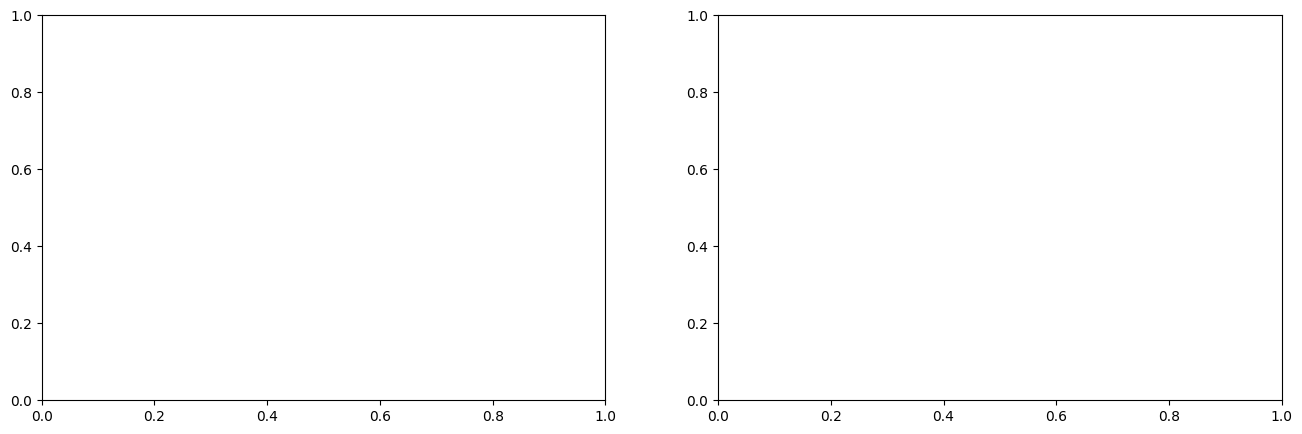

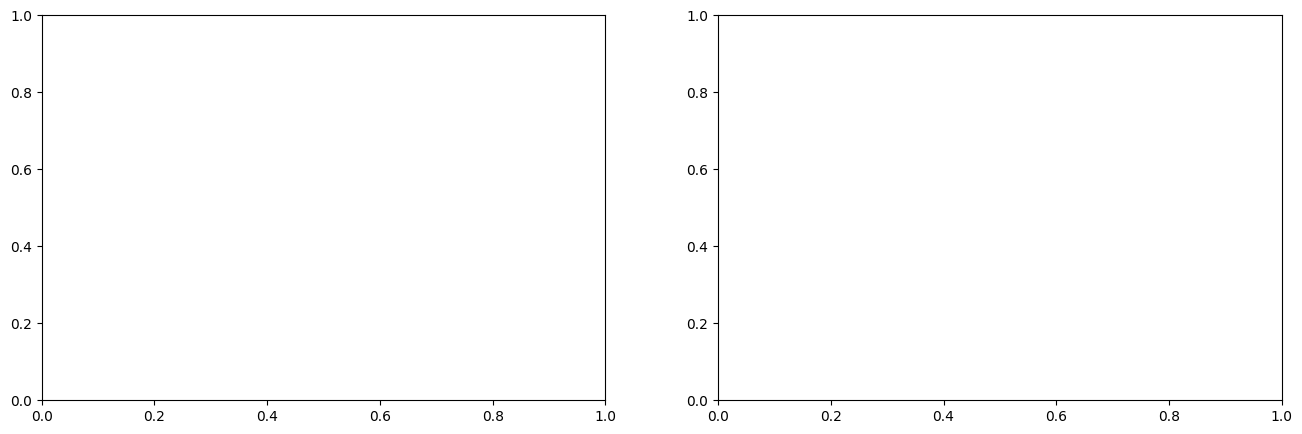

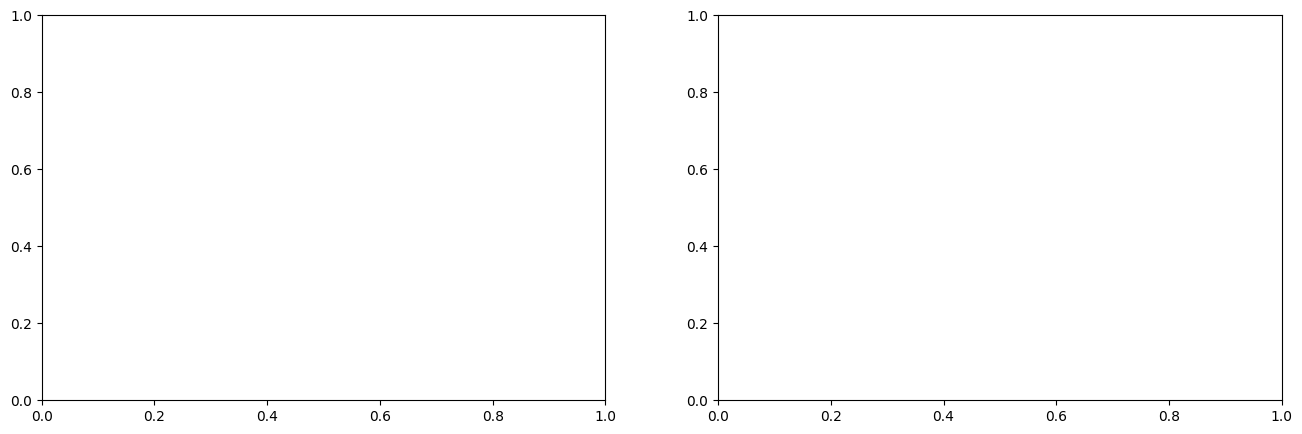

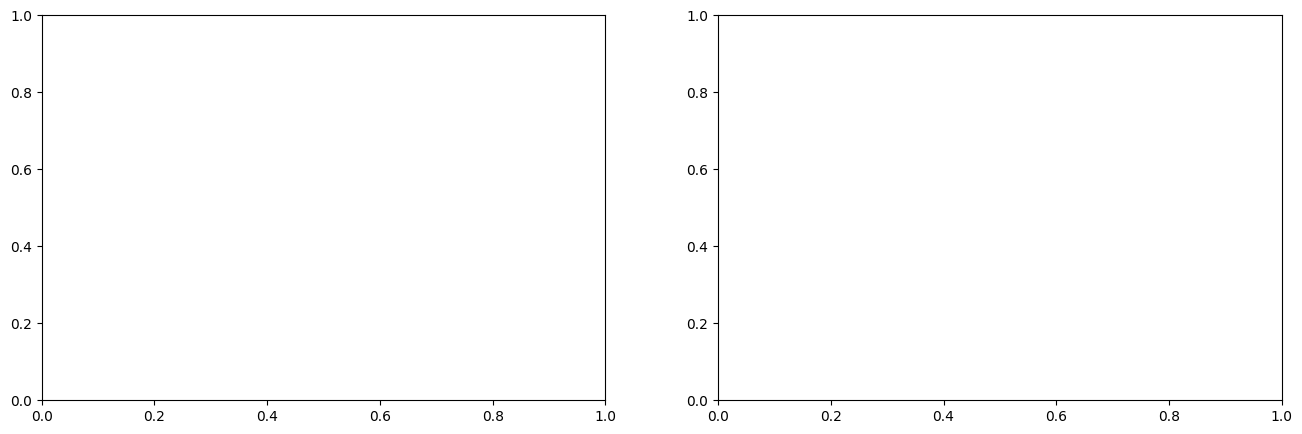

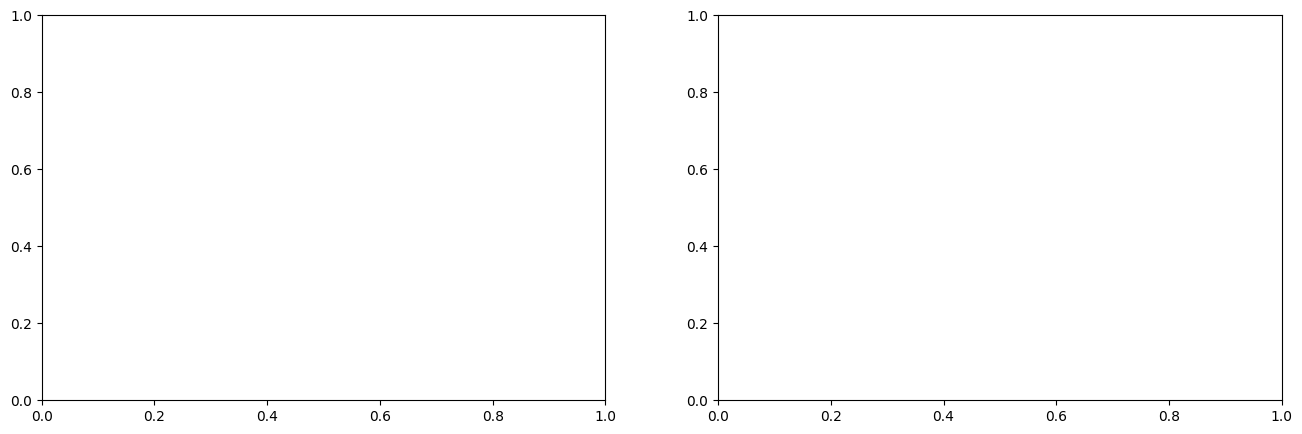

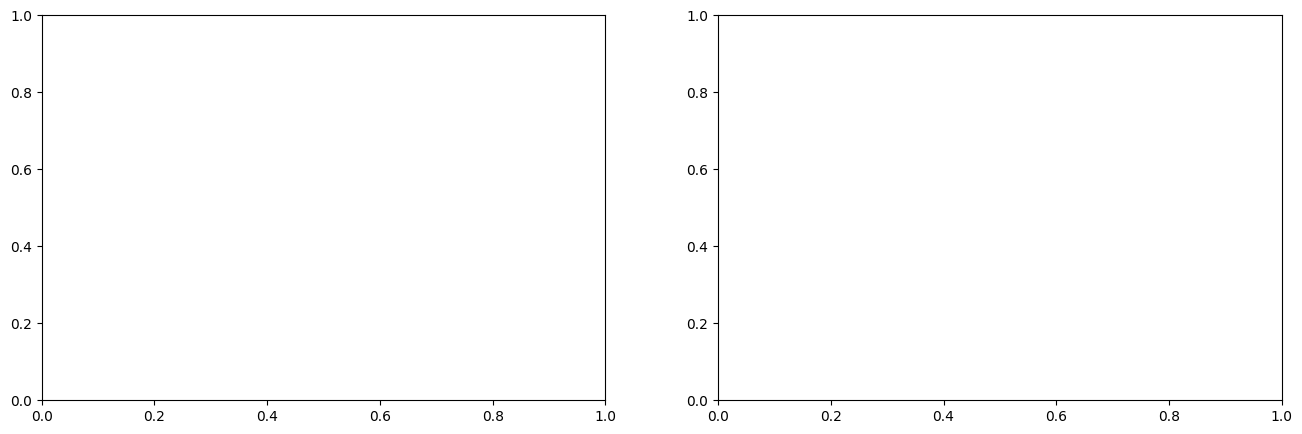

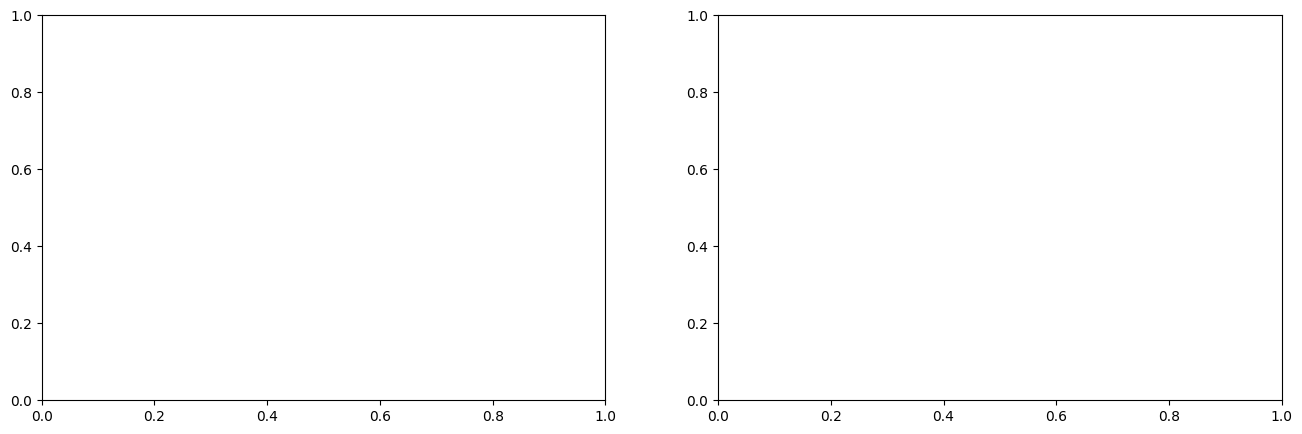

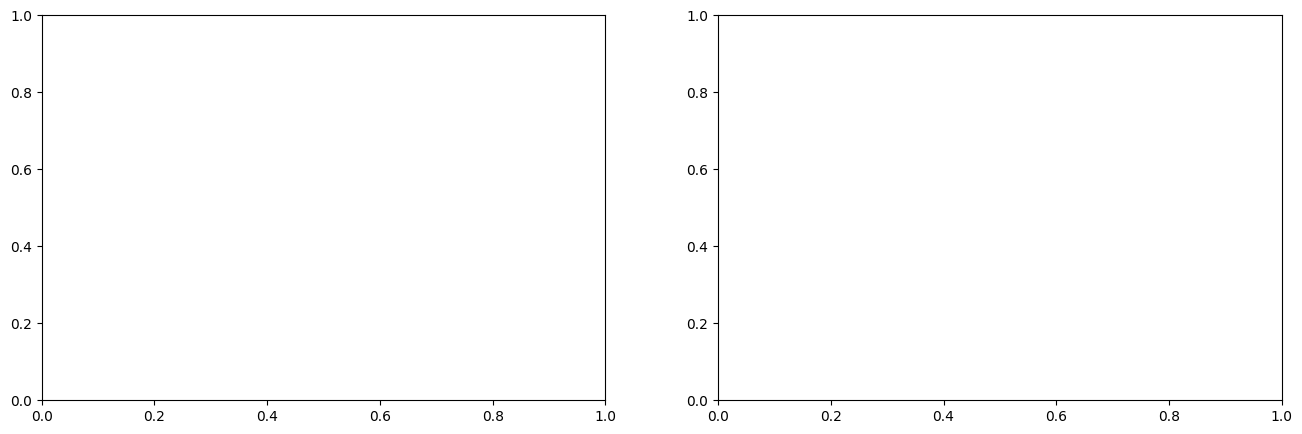

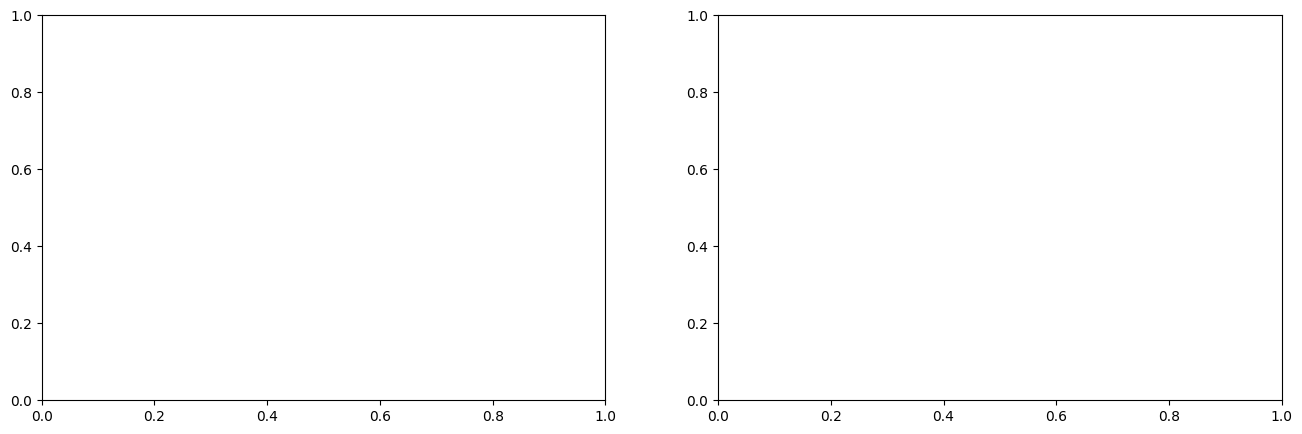

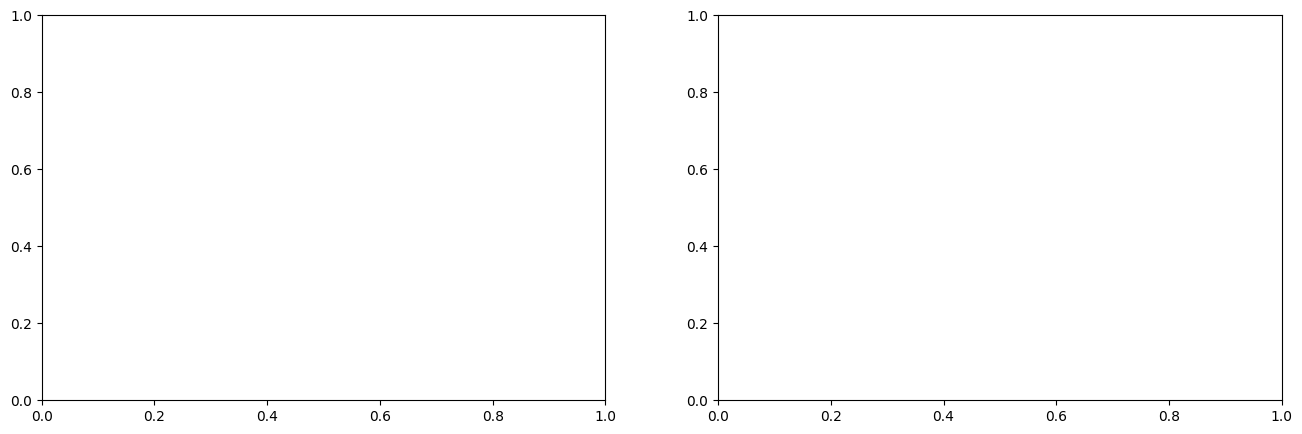

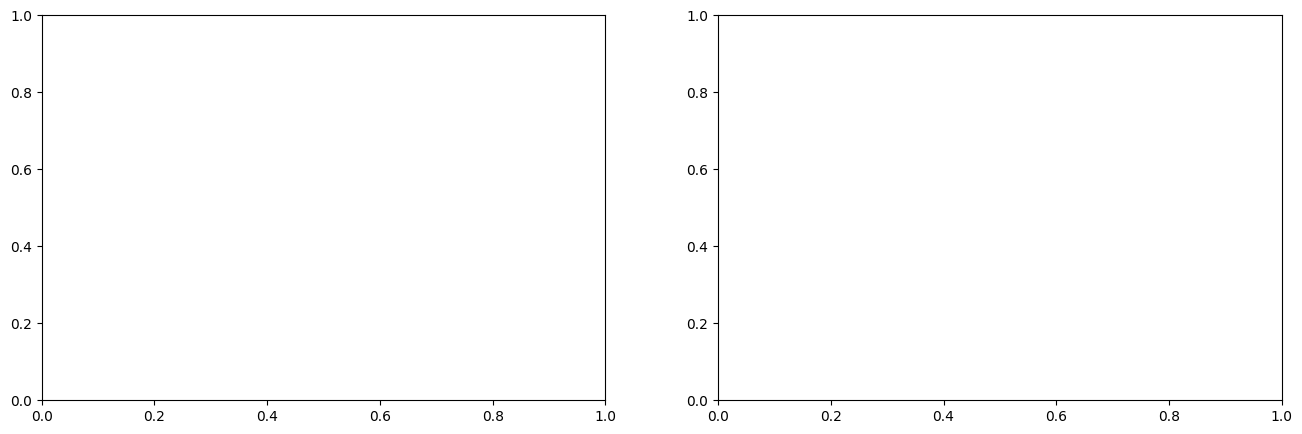

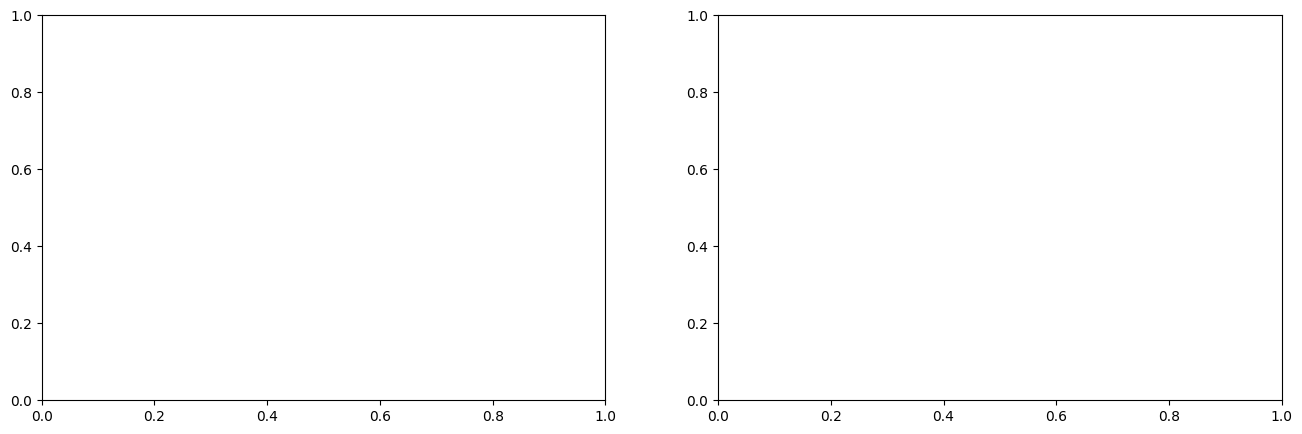

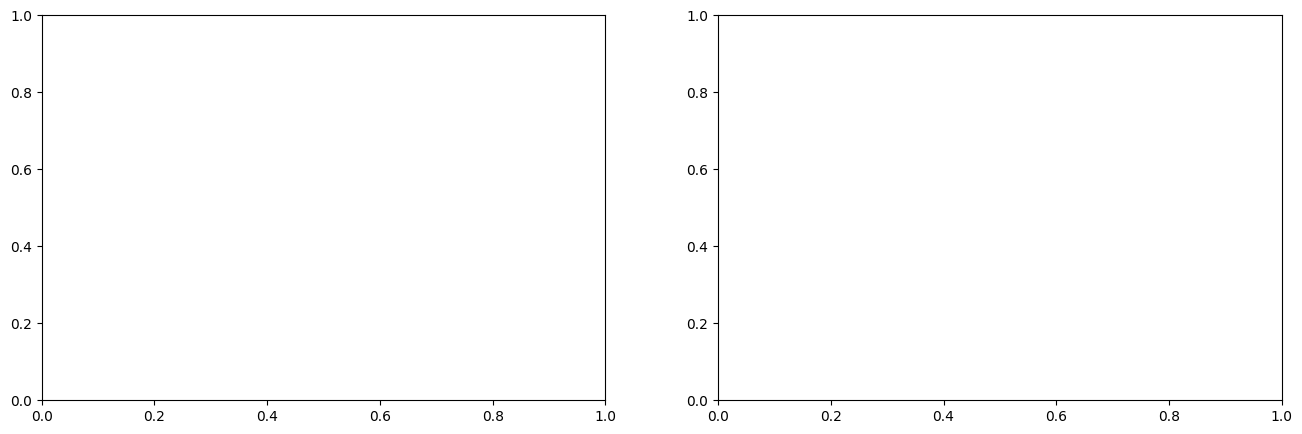

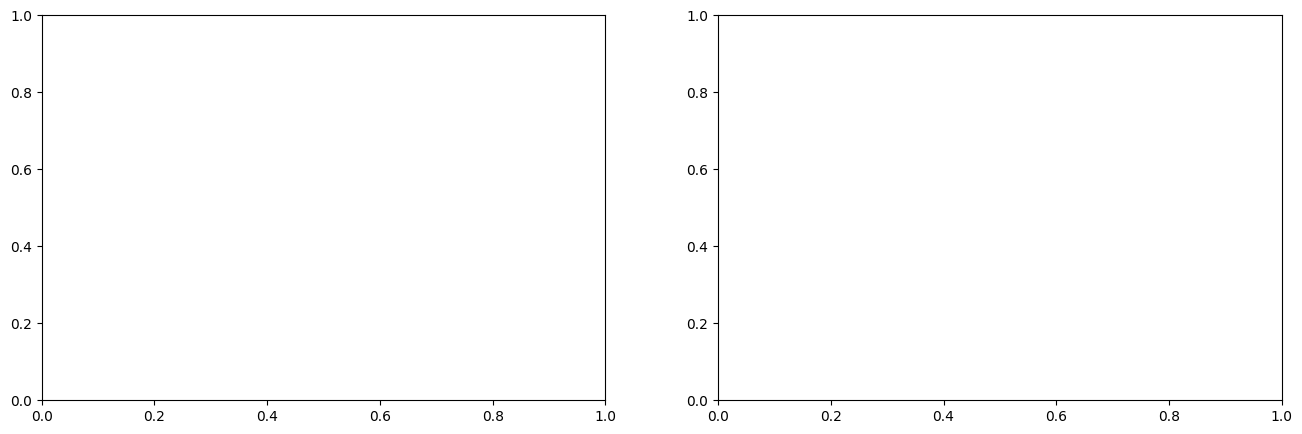

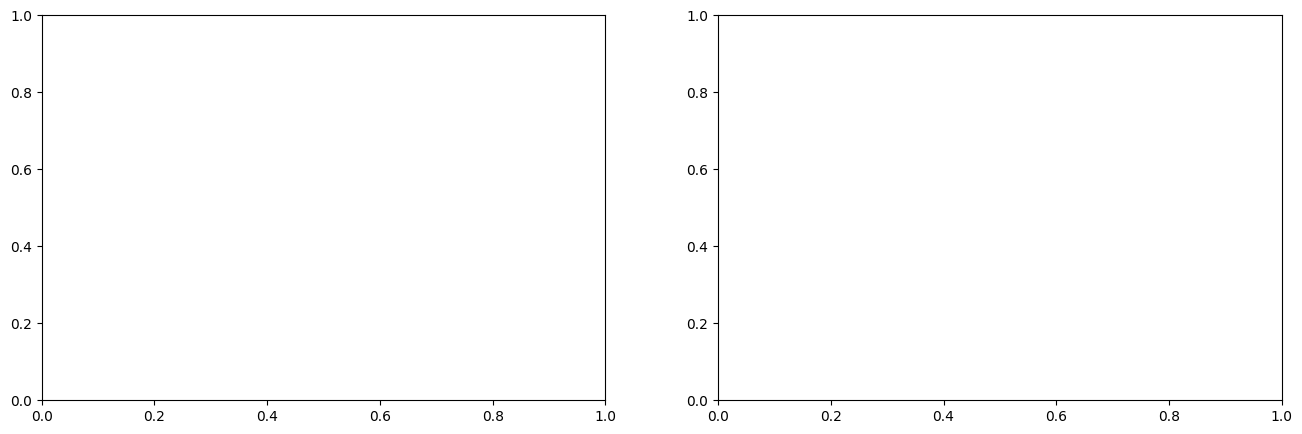

In [28]:
import optuna

def objective_mlp(trail):
    # define the hyper-parameters
    lr=trail.suggest_float("lr", 1e-5, 1e-1, log=True)
    weight_decay=trail.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
    dropout=trail.suggest_float("dropout", 0.2, 0.7)
    opt_name=trail.suggest_categorical("optimizer", ["Adam", "SGD"])
    hidden_dim=trail.suggest_int("hidden_size", 64, 512)
    
    # define models' parameteres
    in_ch=torch.flatten(df_train, start_dim=1, end_dim=-1).shape[1]
    in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, hidden_dim, dropout, kernel=3)
    model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

    # define the optimizer
    optimizer=optim.AdamW(
        model.parameters(),lr=lr,
        weight_decay=weight_decay) if opt_name == "Adam" else optim.SGD(
        model.parameters(),lr=lr,
        weight_decay=weight_decay
    )
    # specify the number of epochs
    # early stopping is applied
    num_epochs=30
    acc=train(model, num_epochs, batch_size=2000, lr=0, weight_decay=0, tune=True, optim=optimizer, trail=trail)

    return acc

study=optuna.create_study(direction="minimize")
study.optimize(objective_mlp, n_trials=15)
print_tun_stat(study)
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)